In [1]:
import sys, os

repo_src = "/victoriapvc/repos/transformers_with_dietcorp_cp/src"

# drop any brain2text paths
sys.path = [p for p in sys.path if "brain2text" not in p]
os.environ["PYTHONPATH"] = ":".join([
	p for p in os.environ.get("PYTHONPATH", "").split(":") if "brain2text" not in p
])

# ensure our repo is first
if repo_src not in sys.path:
	sys.path.insert(0, repo_src)
os.environ["PYTHONPATH"] = repo_src + ":" + os.environ.get("PYTHONPATH", "")

# clear cached modules
for m in [k for k in list(sys.modules) if k.startswith("neural_decoder")]:
	del sys.modules[m]

import neural_decoder.dataset as dataset_module
print("Importing dataset from:", dataset_module.__file__)

Importing dataset from: /victoriapvc/repos/transformers_with_dietcorp_cp/src/neural_decoder/dataset.py


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# These lines are shell commands and not valid Python; they should be set in the environment or in a shell script.
import os

# Set up environment variable for Python module search path if running in Jupyter
os.environ['PYTHONPATH'] = "/victoriapvc/repos/transformers_with_dietcorp_cp/src:" + os.environ.get('PYTHONPATH', '')

# Optionally unset PYTORCH_CUDA_ALLOC_CONF if needed
os.environ.pop('PYTORCH_CUDA_ALLOC_CONF', None)

'max_split_size_mb:128,expandable_segments:True'

In [2]:
# These lines are shell commands and not valid Python; they should be set in the environment or in a shell script.
import os

# Set up environment variable for Python module search path if running in Jupyter
os.environ['PYTHONPATH'] = "/victoriapvc/repos/transformers_with_dietcorp_cp/src:" + os.environ.get('PYTHONPATH', '')

# Optionally unset PYTORCH_CUDA_ALLOC_CONF if needed
os.environ.pop('PYTORCH_CUDA_ALLOC_CONF', None)

'max_split_size_mb:128,expandable_segments:True'

In [3]:
# Run this once per kernel
%load_ext autoreload
%autoreload 2
# Prevent autoreload from reloading PyTorch internals (can break on reload)
%aimport -torch
%aimport -torch.*
import re
import time
import pickle
import numpy as np
import sys
from edit_distance import SequenceMatcher
import torch
from dataset import SpeechDataset
import matplotlib.pyplot as plt
from neural_decoder.dataset import getDatasetLoaders
import neural_decoder.lm_utils as lmDecoderUtils
from neural_decoder.model import GRUDecoder
import pickle
import argparse
import matplotlib.pyplot as plt
from neural_decoder.dataset import getDatasetLoaders
import neural_decoder.lm_utils as lmDecoderUtils
from neural_decoder.lm_utils import build_llama_1B
from neural_decoder.model import GRUDecoder
from neural_decoder.bit import BiT_Phoneme
import pickle
import argparse
from lm_utils import _cer_and_wer
import json
import os
import copy
from torch.utils.data import ConcatDataset
from loss import memo_loss_from_logits, forward_ctc
from collections import deque

import wandb
import math

from tta_utils import convert_sentence, compute_lambda, clean_transcription, get_phonemes, get_data_file, reverse_dataset, get_dataloader, decode_sequence

/opt/conda/lib/python3.10/site-packages/wandb/sdk/internal/internal_api.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [4]:
saveFolder_data = "/victoriapvc/results/paper_results_wer/"
saveFolder_transcripts = "/victoriapvc/data/model_transcriptions_comp/"

In [5]:
base_dir = "/victoriapvc/data/willett"

load_lm = True

# LM decoding hyperparameters
acoustic_scale = 0.8
blank_penalty = np.log(2)

run_for_llm = False

if run_for_llm:
	return_n_best = True
	rescore = False
	nbest = 100
	print("RUNNING IN LLM MODE")
else:
	return_n_best = False
	rescore = False
	nbest = 1
	print("RUNNING IN N-GRAM MODE")
	
if load_lm and 'ngramDecoder' not in globals():
		
	lmDir = base_dir +'/lm/languageModel'
	ngramDecoder = lmDecoderUtils.build_lm_decoder(
		lmDir,
		acoustic_scale=acoustic_scale, #1.2
		nbest=nbest,
		beam=18
	)
	print("loaded LM")
	
elif load_lm:
	print("Already loaded LM")
	

RUNNING IN N-GRAM MODE
loaded LM


I0212 01:10:06.477280 38204 brain_speech_decoder.h:52] Reading fst /victoriapvc/data/willett/lm/languageModel/TLG.fst
I0212 01:12:39.531635 38204 brain_speech_decoder.h:81] Reading symbol table /victoriapvc/data/willett/lm/languageModel/words.txt


In [ ]:
#models_to_run = ['gru_held_out_days_redo']
# all_models = [
# 	"baseline_big0_150steps_for_replication_corrected_y_time_masked_transformer_with_specaugment0075_20masks_0channels_0maxchannels_Ebrahim_seed_0",
# 	's011_rep2_lam0.5_lrm1_wup5_hid256_dcp0_dd0_alpalt_seed_1', 
# ]

all_models = [
'20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1'
]
# all_models = [
# 	"baseline_big0_150steps_for_replication_corrected_y_time_masked_transformer_with_specaugment0075_20masks_0channels_0maxchannels_Ebrahim_seed_0",
# 	"fix_12_0_4_balanced_valid_frameonly_random_tgt_nomeanpool_noreg_noAug_mean_dom_BCE_MDAN_GRL_real_250ep_05src_05tgt_lambda_5e_1_warmup0noGRLstillTrainDisc_lr1x_layer4_MLP_nodrop_ohidden256_inputDrop00_gradclip_1_std_alpha_lr_1e4_no_step_seed_0"
# 	]
# '12_0_4_balanced_valid_frameonly_random_tgt_nomeanpool_noreg_noAug_mean_dom_BCE_MDAN_GRL_real_250ep_05src_05tgt_lambda_1e_0_warmup0noGRLstillTrainDisc_lr1x_layer0_MLP_nodrop_ohidden256_inputDrop00_gradclip_1_std_alpha_lr_1e4_no_step',
			#   'transformer_short_held_out_normal', 
			#   'gru_nonoverlapping_4_4_fixed',
			#   'gru_shortened']

idx = 0
models_to_run = all_models
print(models_to_run[0])
# print(models_to_run[1])
dataset_base_path = '/victoriapvc/data/'
model_base_path = '/victoriapvc/data/outputs/'

if idx == 0 or idx == 1 or idx == -1 or idx == -2:
	data_file = f'{dataset_base_path}/ptDecoder_ctc_both_held_out_days_big_0'
	heldout_data_file = f'{dataset_base_path}/ptDecoder_ctc_both_last3days'
elif idx == 2:
	data_file = f'{dataset_base_path}/ptDecoder_ctc_both_held_out_days'
elif idx == 4:
	data_file = f'{dataset_base_path}/ptDecoder_ctc_both_held_out_days_big_1'
elif idx == 5:
	data_file = f'{dataset_base_path}/ptDecoder_ctc_both_held_out_days_12_0_4'
	heldout_data_file = f'{dataset_base_path}/ptDecoder_ctc_both_last7days'
else:
	data_file = None

shared_output_file = 'transformer_held_out_more_dietcorp_updated'
val_save_file = 'SCRATCH'

output_file = 'leia'
device = "cuda:2"


model_storage_path = '/victoriapvc/data/outputs/'


seeds_list = [0]

if len(shared_output_file) > 0:
	write_mode = "a"
else:
	write_mode = "w"
	

blank_id = 0
num_classes = 41

# no tta
baseline_args = {
	'dropout': 0, 
	'input_dropout': 0, 
	'max_mask_pct': 0, 
	'num_masks': 0, 
	'gru': False, 
	'max_day': 14,
	'repeats': [1]
}

# corp
corp_args = {
	'learning_rate': [1e-3], 
	'repeats': [64],
	'adaptation_steps': 1,
	'WN+BS': True,
	'white_noise': 0.2,
	'baseline_shift': 0.05,
	'dropout': 0.35, 
	'input_dropout': 0.2, 
	'l2_decay': 1e-5, 
	'max_mask_pct': 0.075, 
	'num_masks': 20, 
	'freeze_patch': False,
	'freeze_linear': True,
	'gru': True, 
	'max_day': None
}


tta_mode = 'baseline'

if tta_mode == 'corp':
	updated_args = corp_args  
else:
	updated_args = baseline_args

skip_models = []
skip_seeds = []
print(heldout_data_file)

20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1
/victoriapvc/data//ptDecoder_ctc_both_last3days


In [7]:
def get_lm_outputs(tf_logits):
	
	# prepare logits for n-gram language model decoding 
	logits_np = tf_logits.detach().cpu().numpy()
	logits_np = np.concatenate([
		logits_np[:, :, 1:],   # classes 1 to C-1
		logits_np[:, :, 0:1]   # class 0, preserved in its own dimension
	], axis=-1)
	
	logits_np = lmDecoderUtils.rearrange_speech_logits(logits_np, has_sil=True)
	
	# obtain sentence from n-gram language model 
	decoded = lmDecoderUtils.lm_decode(
		ngramDecoder, logits_np[0],
		blankPenalty=blank_penalty,
		returnNBest=return_n_best, rescore=rescore
	)

	decoded = clean_transcription(decoded)
	
	y_pseudo, y_len_pseudo = get_phonemes(decoded)
	
	return decoded, y_pseudo, y_len_pseudo


In [8]:
updated_args

{'dropout': 0,
 'input_dropout': 0,
 'max_mask_pct': 0,
 'num_masks': 0,
 'gru': False,
 'max_day': 14,
 'repeats': [1]}

In [9]:
def forward_ctc(
		encoder_out: torch.Tensor,
		encoder_out_lens: torch.Tensor,
		targets: torch.Tensor,
		target_lengths: torch.Tensor,
) -> torch.Tensor:
		"""Compute CTC loss.
		Args:
			encoder_out:
				Encoder output, of shape (N, T, C).
			encoder_out_lens:
				Encoder output lengths, of shape (N,).
			targets:
				Target Tensor of shape (sum(target_lengths)). The targets are assumed
				to be un-padded and concatenated within 1 dimension.
		"""
		# Compute CTC log-prob
		ctc_output = encoder_out.log_softmax(2) # (N, T, C)

		device = encoder_out.device
		ctc_loss = torch.nn.functional.ctc_loss(
				log_probs=ctc_output.permute(1, 0, 2),  # (T, N, C)
				targets=targets.to(device),
				input_lengths=encoder_out_lens.to(device),
				target_lengths=target_lengths.to(device),
				reduction="mean",
		)
		return ctc_loss

In [10]:

def run_tta_eval_baseline_vs_dann(
	models_to_run,
	model_storage_path,
	device,
	updated_args,
	tta_mode,
	data_file=None,
	init_from_ckpt=None,        # NEW: {"baseline": "...pth", "dann": "...pth"}
    save_tta_ckpt_dir=None,     # NEW: e.g. "/victoriapvc/tta_ckpts/valrun1"
):
	"""
	Runs eval (optionally with TTA) for baseline + dann (first two models in models_to_run),
	and returns the final (post-TTA) model objects so you can do additional eval (e.g., PER per day).

	Returns:
	  out: dict with
		- n_augs
		- data_file (resolved)
		- baseline: {"model": model, "args": args, "modelPath": str, "wer_total": float, "per_day_wer": list}
		- dann:     {"model": model, "args": args, "modelPath": str, "wer_total": float, "per_day_wer": list}
		- all_* dicts (same as before)
	"""
	import numpy as np
	import pickle
	import torch

	n_augs = updated_args["repeats"][0]

	all_per_day_wer_baseline_val_tta = {}
	all_per_day_wer_dann_val_tta = {}
	all_wer_baseline_val_tta = {}
	all_wer_dann_val_tta = {}

	print(f"{tta_mode}")

	out = {
		"n_augs": n_augs,
		"data_file": None,
		"baseline": None,
		"dann": None,
		"all_per_day_wer_baseline_val_tta": all_per_day_wer_baseline_val_tta,
		"all_wer_baseline_val_tta": all_wer_baseline_val_tta,
		"all_per_day_wer_dann_val_tta": all_per_day_wer_dann_val_tta,
		"all_wer_dann_val_tta": all_wer_dann_val_tta,
	}

	for mn, model_name_str in enumerate(models_to_run):
		print(f"Running model: {model_name_str}")
		modelPath = f"{model_storage_path}{model_name_str}"

		with open(f"{modelPath}/args", "rb") as handle:
			args = pickle.load(handle)

		if "nClasses_2" not in args:
			args["nClasses_2"] = None
		if "normalize_features" not in args or args["normalize_features"] is None:
			args["normalize_features"] = False

		# --- build model ---
		if "baseline" in model_name_str:
			print(f"{model_name_str} is a baseline model")
			from bit import BiT_Phoneme
			model = BiT_Phoneme(
				patch_size=args["patch_size"], dim=args["dim"], dim_head=args["dim_head"],
				nClasses=args["nClasses"], depth=args["depth"], heads=args["heads"],
				mlp_dim_ratio=args["mlp_dim_ratio"],
				dropout=updated_args["dropout"], input_dropout=updated_args["input_dropout"],
				gaussianSmoothWidth=args["gaussianSmoothWidth"],
				T5_style_pos=args["T5_style_pos"], max_mask_pct=updated_args["max_mask_pct"],
				num_masks=updated_args["num_masks"], mask_token_zeros=args["mask_token_zero"],
				max_mask_channels=0, num_masks_channels=0, dist_dict_path=None,
				nClasses_2=args["nClasses_2"],
				consistency=args["consistency"],
			).to(device)
			model_key = "baseline"
		else:
			print(f"{model_name_str} is a DANN model")
			from bit_dann import BiT_Phoneme
			if "mask_token_zero" not in args:
				args["mask_token_zero"] = False
			if "nClasses_2" not in args:
				args["nClasses_2"] = None
			if "normalize_features" not in args or args["normalize_features"] is None:
				args["normalize_features"] = False

			model = BiT_Phoneme(
				patch_size=args["patch_size"],
				dim=args["dim"],
				dim_head=args["dim_head"],
				nClasses=args["nClasses"],
				nClasses_2=args["nClasses_2"],
				depth=args["depth"],
				heads=args["heads"],
				mlp_dim_ratio=args["mlp_dim_ratio"],
				dropout=args["dropout"],
				input_dropout=args["input_dropout"],
				gaussianSmoothWidth=args["gaussianSmoothWidth"],
				T5_style_pos=args["T5_style_pos"],
				max_mask_pct=args["max_mask_pct"],
				num_masks=args["num_masks"],
				mask_token_zeros=args["mask_token_zero"],
				num_masks_channels=args["num_masks_channels"],
				max_mask_channels=args["max_mask_channels"],
				dist_dict_path=args["dist_dict_path"],
				consistency=args["consistency"],
				bottleneck_dim=args["bottleneck_dim"],
				normalize_features=args["normalize_features"],
			).to(device)
			model_key = "dann"

		if hasattr(model, "gaussianSmoother"):
			model.gaussianSmoother.weight = model.gaussianSmoother.weight.to(device)

		# --- load data ---
		if data_file is None:
			data_file = args["datasetPath"]
			print(data_file)
		out["data_file"] = data_file

		trainLoader, testLoaders, loadedData = getDatasetLoaders(data_file, 64)
		args.setdefault("mask_token_zero", False)

		# --- load weights ---
		ckpt_path = None
		if init_from_ckpt is not None:
			ckpt_path = init_from_ckpt.get(model_key, None)

		if ckpt_path is None:
			ckpt_path = f"{modelPath}/modelWeights"

		state = torch.load(ckpt_path, map_location=device)
		model.load_state_dict(state, strict=True)
		print(f"[init] {model_key} loaded from: {ckpt_path}")
		# model.load_state_dict(torch.load(f"{modelPath}/modelWeights", map_location=device), strict=True)

		# --- optimizer + freezing for TTA ---
		optimizer = None
		if tta_mode != "baseline":
			print(updated_args["learning_rate"][mn])
			optimizer = torch.optim.AdamW(
				model.parameters(),
				lr=updated_args["learning_rate"][mn],
				weight_decay=updated_args["l2_decay"],
				betas=(args["beta1"], args["beta2"]),
			)

			if updated_args["freeze_linear"]:
				for name, p in model.named_parameters():
					p.requires_grad = name in {"dayWeights", "dayBias"}

			if updated_args["freeze_patch"]:
				print("unfreezing patch")
				for name, p in model.named_parameters():
					p.requires_grad = name in {
						"to_patch_embedding.1.weight", "to_patch_embedding.1.bias",
						"to_patch_embedding.2.weight", "to_patch_embedding.2.bias",
						"to_patch_embedding.3.weight", "to_patch_embedding.3.bias",
					}

			if not any(p.requires_grad for p in model.parameters()):
				print("Warning: no trainable params after freezing; unfreezing all.")
				for p in model.parameters():
					p.requires_grad = True

		# --- eval loop (and TTA happens inside) ---
		testDayIdxs = np.arange(len(loadedData["test"]))
		print(len(testDayIdxs))

		decoded_list_all_days = []
		transcripts_all_days = []
		per_day_wer_tmp = []

		for test_day_idx, _ in enumerate(testDayIdxs):
			print("day ", test_day_idx)

			val_ds = SpeechDataset([loadedData["test"][test_day_idx]], return_transcript=True)
			data_loader = get_dataloader(val_ds)

			transcriptions_list = []
			decoded_list = []

			for trial_idx, (X, y, X_len, y_len, day_idx, transcript) in enumerate(data_loader):
				X, y, X_len, y_len = map(lambda x: x.to(device), [X, y, X_len, y_len])

				if updated_args["max_day"] is not None:
					day_idx = torch.tensor([updated_args["max_day"]], dtype=torch.int64).to(device)
				else:
					day_idx = torch.tensor([day_idx], dtype=torch.int64).to(device)

				adjusted_len = model.compute_length(X_len)

				model.eval()
				logits_eval = model(X, X_len, day_idx)
				decoded, y_pseudo, y_len_pseudo = get_lm_outputs(logits_eval)

				if tta_mode != "baseline":
					if n_augs > 0:
						X = X.repeat(n_augs, 1, 1)
						y = y.repeat(n_augs, 1)
						y_len = y_len.repeat(n_augs)
						X_len = X_len.repeat(n_augs)
						adjusted_len = adjusted_len.repeat(n_augs)
						y_pseudo = y_pseudo.unsqueeze(0).repeat(n_augs, 1).to(device)
						y_len_pseudo = y_len_pseudo.repeat(n_augs).to(device)

					if updated_args["WN+BS"] == True:
						X += torch.randn(X.shape, device=device) * updated_args["white_noise"]
						X += (
							torch.randn([X.shape[0], 1, X.shape[2]], device=device)
							* updated_args["baseline_shift"]
						)

					model.train()
					for _ in range(updated_args["adaptation_steps"]):
						logits = model(X, X_len, day_idx)
						corp_loss = forward_ctc(logits, adjusted_len, y_pseudo, y_len_pseudo)
						optimizer.zero_grad()
						corp_loss.backward()
						torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
						optimizer.step()
					model.eval()

				decoded_list.append(decoded)
				transcriptions_list.append(clean_transcription(transcript[0]))

			_, wer = _cer_and_wer(decoded_list, transcriptions_list, outputType="speech", returnCI=False)
			print("DAY WER: ", wer)
			per_day_wer_tmp.append(wer)

			decoded_list_all_days.extend(decoded_list)
			transcripts_all_days.extend(transcriptions_list)

		_, wer_total = _cer_and_wer(decoded_list_all_days, transcripts_all_days, outputType="speech", returnCI=False)
		print("WER ACROSS DAYS: ", wer_total)

		tta_ckpt_path = None
		if save_tta_ckpt_dir is not None and tta_mode != "baseline":
			os.makedirs(save_tta_ckpt_dir, exist_ok=True)
			tta_ckpt_path = os.path.join(save_tta_ckpt_dir, f"{model_key}_posttta.pth")
			torch.save(model.state_dict(), tta_ckpt_path)
			print(f"[save] {model_key} Val-trained post-TTA saved to: {tta_ckpt_path}")

		# store per-model results + return model itself
		out[model_key] = {
			"model": model,
			"args": args,
			"modelPath": modelPath,
			"wer_total": wer_total,
			"per_day_wer": per_day_wer_tmp,
			"tta_ckpt_path": tta_ckpt_path,   # NEW
		}

		# also fill the old dicts keyed by n_augs
		if model_key == "baseline":
			out["all_per_day_wer_baseline_val_tta"][n_augs] = per_day_wer_tmp
			out["all_wer_baseline_val_tta"][n_augs] = wer_total
		else:
			out["all_per_day_wer_dann_val_tta"][n_augs] = per_day_wer_tmp
			out["all_wer_dann_val_tta"][n_augs] = wer_total

	return out


# Validation (target) set without TTA


In [11]:
baseline_args = {
	'dropout': 0, 
	'input_dropout': 0, 
	'max_mask_pct': 0, 
	'num_masks': 0, 
	'gru': False, 
	'max_day': 14,
	'repeats': [1]
}
tta_mode = 'baseline'
baseline_args


{'dropout': 0,
 'input_dropout': 0,
 'max_mask_pct': 0,
 'num_masks': 0,
 'gru': False,
 'max_day': 14,
 'repeats': [1]}

In [13]:
data_file

'/victoriapvc/data//ptDecoder_ctc_both_held_out_days_big_0'

In [14]:
print("Computing no TTA on Val set")
out_val_set_without_tta = run_tta_eval_baseline_vs_dann(
	models_to_run=models_to_run,
	model_storage_path=model_storage_path,
	device=device,
	updated_args=baseline_args,
	tta_mode=tta_mode,
	data_file=data_file,   # or pass your explicit path
)
print(out_val_set_without_tta["baseline"]["per_day_wer"], out_val_set_without_tta["baseline"]["wer_total"])

Computing no TTA on Val set
baseline
Running model: 20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1
20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1 is a DANN model


/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[init] dann loaded from: /victoriapvc/data/outputs/20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1/modelWeights
8
day  0


/victoriapvc/repos/transformers_with_dietcorp_cp/src/neural_decoder/augmentations.py:170: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:895.)
  return self.conv(input, weight=self.weight, groups=self.groups, padding="same")
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


DAY WER:  0.29709848794442173
day  1
DAY WER:  0.3102267864783911
day  2
DAY WER:  0.3609865470852018
day  3
DAY WER:  0.41821561338289964
day  4
DAY WER:  0.44792064097672646
day  5
DAY WER:  0.43594504270330486
day  6
DAY WER:  0.4767704104645918
day  7
DAY WER:  0.5256588072122053
WER ACROSS DAYS:  0.4074279379157428


TypeError: 'NoneType' object is not subscriptable

### pre TTA PER per day

In [ ]:
def load_bit_adv_phoneme_model(folder, n_domains, device='cuda', isbaseline=False):
	"""Load a BiT_Phoneme model from a folder containing 'args' and 'modelWeights'."""
	# Load args
	args_path = os.path.join(folder, "args")
	with open(args_path, "rb") as handle:
		args = pickle.load(handle)

	# Instantiate model

	if isbaseline:
		from bit import BiT_Phoneme
		model = BiT_Phoneme(
			patch_size=args['patch_size'],
			dim=args['dim'],
			dim_head=args['dim_head'],
			nClasses=args['nClasses'],
			nClasses_2=args['nClasses_2'],
			depth=args['depth'],
			heads=args['heads'],
			mlp_dim_ratio=args['mlp_dim_ratio'],
			dropout=args['dropout'],
			input_dropout=args['input_dropout'],
			gaussianSmoothWidth=args['gaussianSmoothWidth'],
			T5_style_pos=args['T5_style_pos'],
			max_mask_pct=args['max_mask_pct'],
			num_masks=args['num_masks'],
			mask_token_zeros=args['mask_token_zero'],
			num_masks_channels=args['num_masks_channels'],
			max_mask_channels=args['max_mask_channels'],
			dist_dict_path=args['dist_dict_path'],
			consistency=args['consistency'],
		).to(device)
		disc = None
	else:
		from bit_dann import BiT_Phoneme
		from dann import DomainDiscriminator

		# Ensure defaults
		if 'mask_token_zero' not in args:
			args['mask_token_zero'] = False
		if 'nClasses_2' not in args:
			args['nClasses_2'] = None
		if 'normalize_features' not in args or args['normalize_features'] is None:
			args['normalize_features'] = False

		model = BiT_Phoneme(
			patch_size=args['patch_size'],
			dim=args['dim'],
			dim_head=args['dim_head'],
			nClasses=args['nClasses'],
			nClasses_2=args['nClasses_2'],
			depth=args['depth'],
			heads=args['heads'],
			mlp_dim_ratio=args['mlp_dim_ratio'],
			dropout=args['dropout'],
			input_dropout=args['input_dropout'],
			gaussianSmoothWidth=args['gaussianSmoothWidth'],
			T5_style_pos=args['T5_style_pos'],
			max_mask_pct=args['max_mask_pct'],
			num_masks=args['num_masks'],
			mask_token_zeros=args['mask_token_zero'],
			num_masks_channels=args['num_masks_channels'],
			max_mask_channels=args['max_mask_channels'],
			dist_dict_path=args['dist_dict_path'],
			consistency=args['consistency'],
			bottleneck_dim=args['bottleneck_dim'],
			normalize_features=args['normalize_features'],
		).to(device)

		if args['bottleneck_dim'] is not None:
			in_dim = args['bottleneck_dim']
		else:
			in_dim = args['dim']

		disc = torch.nn.ModuleList([
			DomainDiscriminator(
				in_dim=in_dim,
				hidden_dim=args['dann_hidden'],
				n_domains=1,
				dropout=args['domain_dropout'],
				linear_discriminator=args['linear_discriminator'],
			) for _ in range(n_domains)
		]).to(device)

		disc_ckpt_path = os.path.join(folder, "disc_optimizer")
		disc_checkpoint_state_dict = torch.load(disc_ckpt_path, map_location=device)
		disc.load_state_dict(disc_checkpoint_state_dict, strict=False)

		disc = disc.to(device)
		disc.eval()

	# Load weights
	ckpt_path = os.path.join(folder, "modelWeights")
	checkpoint_state_dict = torch.load(ckpt_path, map_location=device)
	model.load_state_dict(checkpoint_state_dict, strict=False)

	model = model.to(device)
	model.eval()

	return model, args, disc

In [ ]:
model_base_path_1 = f'/victoriapvc/data/outputs/{models_to_run[0]}'
model_base_path_2 = f'/victoriapvc/data/outputs/{models_to_run[1]}'

model_1, args_1, disc_1 = load_bit_adv_phoneme_model(model_base_path_1, n_domains=12, isbaseline=True)
model_2, args_2, disc_2 = load_bit_adv_phoneme_model(model_base_path_2, n_domains=12, isbaseline=False)

from lm_utils import evaluate_model
device ='cuda'
_, _, loadedData = getDatasetLoaders(data_file, 64)
for mn, model_name_str in enumerate(models_to_run[:2]):
	model = model_1 if mn == 0 else model_2
	pre_tta_val_outputs, pre_tta_val_cer, pre_tta_per_day_val_cer = evaluate_model(model, loadedData, partition='test', device=device, verbose=True)


# Validation (target) set with TTA

In [18]:
# corp
corp_args = {
	'learning_rate': [1e-3], 
	'repeats': [64],
	'adaptation_steps': 1,
	'WN+BS': True,
	'white_noise': 0.2,
	'baseline_shift': 0.05,
	'dropout': 0.35, 
	'input_dropout': 0.2, 
	'l2_decay': 1e-5, 
	'max_mask_pct': 0.075, 
	'num_masks': 20, 
	'freeze_patch': True,
	'freeze_linear': False,
	'gru': True, 
	'max_day': None
}

tta_mode = 'corp'
corp_args

{'learning_rate': [0.001],
 'repeats': [64],
 'adaptation_steps': 1,
 'WN+BS': True,
 'white_noise': 0.2,
 'baseline_shift': 0.05,
 'dropout': 0.35,
 'input_dropout': 0.2,
 'l2_decay': 1e-05,
 'max_mask_pct': 0.075,
 'num_masks': 20,
 'freeze_patch': True,
 'freeze_linear': False,
 'gru': True,
 'max_day': None}

In [16]:
data_file

'/victoriapvc/data//ptDecoder_ctc_both_held_out_days_big_0'

In [19]:
out_val_set_with_tta = run_tta_eval_baseline_vs_dann(
	models_to_run=models_to_run,
	model_storage_path=model_storage_path,
	device=device,
	updated_args=corp_args,
	tta_mode=tta_mode,
	data_file=data_file,   # or pass your explicit path
	save_tta_ckpt_dir="/victoriapvc/tta_ckpts/val_adapt",
)


corp
Running model: 20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1
20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1 is a DANN model
[init] dann loaded from: /victoriapvc/data/outputs/20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1/modelWeights
0.001
unfreezing patch
8
day  0
DAY WER:  0.2689006947282387
day  1
DAY WER:  0.2631578947368421
day  2
DAY WER:  0.2757847533632287
day  3
DAY WER:  0.27063197026022306
day  4
DAY WER:  0.28157191911484164
day  5
DAY WER:  0.2695878202747865
day  6
DAY WER:  0.2778529544429409
day  7
DAY WER:  0.29172445677300046
WER ACROSS DAYS:  0.27464220923200966
[save] dann Val-trained post-TTA saved to: /victoriapvc/tta_ckpts/val_adapt/dann_posttta.pth


## test if other lr make ours better

In [20]:
# corp
corp_args = {
	'learning_rate': [5e-3], 
	'repeats': [64],
	'adaptation_steps': 1,
	'WN+BS': True,
	'white_noise': 0.2,
	'baseline_shift': 0.05,
	'dropout': 0.35, 
	'input_dropout': 0.2, 
	'l2_decay': 1e-5, 
	'max_mask_pct': 0.075, 
	'num_masks': 20, 
	'freeze_patch': True,
	'freeze_linear': False,
	'gru': True, 
	'max_day': None
}

tta_mode = 'corp'
corp_args

{'learning_rate': [0.005],
 'repeats': [64],
 'adaptation_steps': 1,
 'WN+BS': True,
 'white_noise': 0.2,
 'baseline_shift': 0.05,
 'dropout': 0.35,
 'input_dropout': 0.2,
 'l2_decay': 1e-05,
 'max_mask_pct': 0.075,
 'num_masks': 20,
 'freeze_patch': True,
 'freeze_linear': False,
 'gru': True,
 'max_day': None}

In [53]:
models_to_run[1]

's011_rep2_lam0.5_lrm1_wup5_hid256_dcp0_dd0_alpalt_seed_1'

In [23]:
out_val_set_with_tta = run_tta_eval_baseline_vs_dann(
	models_to_run=models_to_run,
	model_storage_path=model_storage_path,
	device=device,
	updated_args=corp_args,
	tta_mode=tta_mode,
	data_file=data_file,   # or pass your explicit path
	save_tta_ckpt_dir="/victoriapvc/tta_ckpts/val_adapt",
)

corp
Running model: 20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1
20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1 is a DANN model
[init] dann loaded from: /victoriapvc/data/outputs/20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1/modelWeights
0.005
unfreezing patch
8
day  0
DAY WER:  0.2848385778504291
day  1
DAY WER:  0.25759520753102266
day  2
DAY WER:  0.2884902840059791
day  3
DAY WER:  0.27397769516728626
day  4
DAY WER:  0.2548645555131629
day  5
DAY WER:  0.2669884886743409
day  6
DAY WER:  0.2638700947225981
day  7
DAY WER:  0.279704114655571
WER ACROSS DAYS:  0.27136665994759124
[save] dann Val-trained post-TTA saved to: /victoriapvc/tta_ckpts/val_adapt/dann_posttta.pth


### post TTA per day PER

In [ ]:
from lm_utils import evaluate_model
device ='cuda'
for mn, model_name_str in enumerate(models_to_run[:2]):
	model = model_1 if mn == 0 else model_2
	post_tta_val_outputs, post_tta_val_cer, post_tta_per_day_val_cer = evaluate_model(model, loadedData, partition='test', device=device, verbose=True)

# Unseen Test set without TTA

In [21]:
# heldout_data_file = f"{dataset_base_path}{'ptDecoder_ctc_both_last7days'}" # TODO: change if needed
print(heldout_data_file)
_, _, loaded_lastndays_data = getDatasetLoaders(
	heldout_data_file, 8, None, 
	False
)
lastndays_data = loaded_lastndays_data['test']
print(f"Loaded last {len(lastndays_data)} days of Data")

/victoriapvc/data//ptDecoder_ctc_both_last7days
Loaded last 7 days of Data


In [48]:
baseline_args = {
	'dropout': 0, 
	'input_dropout': 0, 
	'max_mask_pct': 0, 
	'num_masks': 0, 
	'gru': False, 
	'max_day': 14,
	'repeats': [1]
}
tta_mode = 'baseline'
baseline_args


{'dropout': 0,
 'input_dropout': 0,
 'max_mask_pct': 0,
 'num_masks': 0,
 'gru': False,
 'max_day': 14,
 'repeats': [1]}

In [49]:
out_unseen_test_set_without_tta = run_tta_eval_baseline_vs_dann(
	models_to_run=models_to_run,
	model_storage_path=model_storage_path,
	device=device,
	updated_args=baseline_args,
	tta_mode=tta_mode,
	data_file=heldout_data_file,   # or pass your explicit path
)
print(out_unseen_test_set_without_tta["baseline"]["per_day_wer"], out_unseen_test_set_without_tta["baseline"]["wer_total"])

baseline
Running model: baseline_big0_150steps_for_replication_corrected_y_time_masked_transformer_with_specaugment0075_20masks_0channels_0maxchannels_Ebrahim_seed_0
[init] baseline loaded from: /victoriapvc/data/outputs/baseline_big0_150steps_for_replication_corrected_y_time_masked_transformer_with_specaugment0075_20masks_0channels_0maxchannels_Ebrahim_seed_0/modelWeights
7
day  0
DAY WER:  0.5852727966425029
day  1
DAY WER:  0.5124396583735611
day  2
DAY WER:  0.6156968876860622
day  3
DAY WER:  0.6578825705039297
day  4
DAY WER:  0.6891891891891891
day  5
DAY WER:  0.7354465102103017
day  6
DAY WER:  0.7591372079089275
WER ACROSS DAYS:  0.6582634512214178
Running model: fix_12_0_4_balanced_valid_frameonly_random_tgt_nomeanpool_noreg_noAug_mean_dom_BCE_MDAN_GRL_real_250ep_05src_05tgt_lambda_5e_1_warmup0noGRLstillTrainDisc_lr1x_layer4_MLP_nodrop_ohidden256_inputDrop00_gradclip_1_std_alpha_lr_1e4_no_step_seed_0
[init] dann loaded from: /victoriapvc/data/outputs/fix_12_0_4_balanced_vali

### pre-TTA per day PER

In [ ]:
from lm_utils import evaluate_model
device ='cuda'
for mn, model_name_str in enumerate(models_to_run[:2]):
	model = model_1 if mn == 0 else model_2
	pre_tta_test_outputs, pre_tta_test_cer, pre_tta_per_day_test_cer = evaluate_model(model, loadedData, partition='test', device=device, verbose=True)

# Unseen Test set with TTA

In [35]:
# corp
corp_args = {
	'learning_rate': [3e-3], 
	'repeats': [64],
	'adaptation_steps': 1,
	'WN+BS': True,
	'white_noise': 0.2,
	'baseline_shift': 0.05,
	'dropout': 0.35, 
	'input_dropout': 0.2, 
	'l2_decay': 1e-5, 
	'max_mask_pct': 0.075, 
	'num_masks': 20, 
	'freeze_patch': True,
	'freeze_linear': False,
	'gru': True, 
	'max_day': None
}

tta_mode = 'corp'
corp_args

{'learning_rate': [0.003],
 'repeats': [64],
 'adaptation_steps': 1,
 'WN+BS': True,
 'white_noise': 0.2,
 'baseline_shift': 0.05,
 'dropout': 0.35,
 'input_dropout': 0.2,
 'l2_decay': 1e-05,
 'max_mask_pct': 0.075,
 'num_masks': 20,
 'freeze_patch': True,
 'freeze_linear': False,
 'gru': True,
 'max_day': None}

In [27]:
start_from_val_trained_model = False

In [28]:
heldout_data_file

'/victoriapvc/data//ptDecoder_ctc_both_last3days'

In [ ]:

if start_from_val_trained_model:
	init_from = {
		"baseline": out_val_set_with_tta["baseline"]["tta_ckpt_path"],
		"dann": out_val_set_with_tta["dann"]["tta_ckpt_path"],
	}

	out_unseen_test_set_with_tta = run_tta_eval_baseline_vs_dann(
		models_to_run=models_to_run,
		model_storage_path=model_storage_path,
		device=device,
		updated_args=corp_args,
		tta_mode=tta_mode,
		data_file=heldout_data_file,   # or pass your explicit path
		init_from_ckpt=init_from,
	)
else:
	out_unseen_test_set_with_tta = run_tta_eval_baseline_vs_dann(
		models_to_run=models_to_run,
		model_storage_path=model_storage_path,
		device=device,
		updated_args=corp_args,
		tta_mode=tta_mode,
		data_file=heldout_data_file,   # or pass your explicit path
	)

print(out_unseen_test_set_with_tta["baseline"]["per_day_wer"], out_unseen_test_set_with_tta["baseline"]["wer_total"])

corp
Running model: 20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1
20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1 is a DANN model
[init] dann loaded from: /victoriapvc/data/outputs/20260209_s019_rep2_lam0.5_lrm1_wup0_hid256_dcp0.2_dd0_alpalt_alf24_seed_1/modelWeights
0.003
unfreezing patch
3
day  0
DAY WER:  0.41995841995842
day  1
DAY WER:  0.37610484608351114
day  2
DAY WER:  0.35829838226482924
WER ACROSS DAYS:  0.38316675433982117


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# corp
corp_args = {
	'learning_rate': [4e-3], 
	'repeats': [64],
	'adaptation_steps': 1,
	'WN+BS': True,
	'white_noise': 0.2,
	'baseline_shift': 0.05,
	'dropout': 0.35, 
	'input_dropout': 0.2, 
	'l2_decay': 1e-5, 
	'max_mask_pct': 0.075, 
	'num_masks': 20, 
	'freeze_patch': True,
	'freeze_linear': False,
	'gru': True, 
	'max_day': None
}

tta_mode = 'corp'
corp_args

## a copy of big0 result

In [ ]:
n_augs = 1
n_augs2 = corp_args["repeats"][0]

out_val_set_without_tta = {
    "all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
    "all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
    "all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
    "all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}

# baseline (no TTA)
out_val_set_without_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
    0.2938291785860237,  # Day 0
    0.33889602053915274, # Day 1
    0.45366218236173395, # Day 2
    0.5315985130111525,  # Day 3
    0.5852727966425029,  # Day 4
    0.5124396583735611,  # Day 5
    0.6156968876860622,  # Day 6
    0.6578825705039297,  # Day 7
]
out_val_set_without_tta["all_wer_baseline_val_tta"][n_augs] = 0.4967244507155815

# ours / dann (no TTA)  (your second model: s011_rep2...)
out_val_set_without_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [
    0.29505516959542294, # Day 0
    0.31065468549422337, # Day 1
    0.35500747384155457, # Day 2
    0.3992565055762082,  # Day 3
    0.45974818771461273, # Day 4
    0.4385443743037505,  # Day 5
    0.4934596301308074,  # Day 6
    0.5219602404068423,  # Day 7
]
out_val_set_without_tta["all_wer_dann_val_tta"][n_augs2] = 0.40722636565208625

n_augs = 1
n_augs2 = corp_args["repeats"][0]

out_val_set_with_tta = {
	"all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
	"all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
	"all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
	"all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}
out_val_set_with_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
	0.26644871270944015,
	0.27899015832263585, # Day 1
	0.27914798206278024, # Day 2
	0.3066914498141264,  # Day 3
	0.30560854635635254, # Day 4
	0.29261047159301895, # Day 5
	0.3071718538565629,  # Day 6
	0.32038834951456313  # Day 7
]
out_val_set_with_tta["all_wer_baseline_val_tta"][n_augs] = 0.2942451118726063

out_val_set_with_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [0.2729873314262362,
	0.2687205819426615,
	0.2739162929745889,
	0.283271375464684,
	0.28195345288057994,
	0.27255848496101004,
	0.2796571944068561,
	0.2644475265834489,]
out_val_set_with_tta["all_wer_dann_val_tta"][n_augs2] = 0.2749445676274945
n_augs = 1
n_augs2 = corp_args["repeats"][0]

out_unseen_test_set_without_tta = {
    "all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
    "all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
    "all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
    "all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}

# baseline (no TTA)
out_unseen_test_set_without_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
    0.6905751905751906,  # Day 0
    0.7354465102103017,  # Day 1
    0.7591372079089275,  # Day 2
]
out_unseen_test_set_without_tta["all_wer_baseline_val_tta"][n_augs] = 0.7301420305102577

# ours / dann (no TTA)  (your second model: s011_rep2...)
out_unseen_test_set_without_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [
    0.56999306999307,    # Day 0
    0.6397439804937519,  # Day 1
    0.6548831635710006,  # Day 2
]
out_unseen_test_set_without_tta["all_wer_dann_val_tta"][n_augs2] = 0.6238821672803787


n_augs = 1
n_augs2 = corp_args["repeats"][0]
out_unseen_test_set_with_tta = {
	"all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
	"all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
	"all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
	"all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}
out_unseen_test_set_with_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
   0.9192654192654193,
	1.0,
	1.0,
]
out_unseen_test_set_with_tta["all_wer_baseline_val_tta"][n_augs] = 0.9754865860073646

out_unseen_test_set_with_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [
 0.46015246015246014,
	0.4120694910088388,
	0.39005392450569204,]
out_unseen_test_set_with_tta["all_wer_dann_val_tta"][n_augs2] = 0.4189374013677012

## a copy of 12_0_4 result

In [4]:
n_augs = 1
n_augs2 = corp_args["repeats"][0]

out_val_set_without_tta = {
    "all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
    "all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
    "all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
    "all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}

out_val_set_without_tta = {
    "all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
    "all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
    "all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
    "all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}

# baseline (no TTA)
out_val_set_without_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
    0.2938291785860237,  # Day 0
    0.33889602053915274, # Day 1
    0.45366218236173395, # Day 2
    0.5315985130111525,  # Day 3
]
out_val_set_without_tta["all_wer_baseline_val_tta"][n_augs] = 0.40935960591133

# ours / dann (no TTA)
out_val_set_without_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [
    0.30445443400081734, # Day 0
    0.3333333333333333, # Day 1
    0.4047085201793722, # Day 2
    0.4728624535315985, # Day 3
]
out_val_set_without_tta["all_wer_dann_val_tta"][n_augs2] = 0.3821674876847291

out_unseen_test_set_with_tta = {
    "all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
    "all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
    "all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
    "all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}
out_val_set_with_tta = {
    "all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
    "all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
    "all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
    "all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}

# baseline (TTA)
out_val_set_with_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
    0.26644871270944015, # Day 0
    0.2734274711168164,  # Day 1
    0.2858744394618834,  # Day 2
    0.3066914498141264,  # Day 3
]
out_val_set_with_tta["all_wer_baseline_val_tta"][n_augs] = 0.2838423645320197

# ours / dann (TTA)
out_val_set_with_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [
    0.2938291785860237,  # Day 0
    0.2601626016260163,  # Day 1
    0.29035874439461884, # Day 2
    0.3282527881040892,  # Day 3
]
out_val_set_with_tta["all_wer_dann_val_tta"][n_augs2] = 0.29428571428571426


# -----------------------
# baseline (TTA)
# -----------------------
out_unseen_test_set_with_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
    0.47272033574971384,  # Day 0
    0.35833642777571484,  # Day 1
    0.3622011727559765,   # Day 2
    0.37956541840036984,  # Day 3
    0.4397089397089397,   # Day 4
    0.9116123133191101,   # Day 5
    1.0,                  # Day 6
]
out_unseen_test_set_with_tta["all_wer_baseline_val_tta"][n_augs] = 0.5951351632897547

# -----------------------
# ours / dann (TTA)
# -----------------------
out_unseen_test_set_with_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [
    0.4380007630675315,   # Day 0
    0.3876717415521723,   # Day 1
    0.37437979251240416,  # Day 2
    0.37309292649098474,  # Day 3
    0.40575190575190573,  # Day 4
    0.45717768972874123,  # Day 5
    0.5413421210305572,   # Day 6
]
out_unseen_test_set_with_tta["all_wer_dann_val_tta"][n_augs2] = 0.4326787853534038

out_unseen_test_set_without_tta = {
    "all_per_day_wer_baseline_val_tta": [[] for _ in range(n_augs + 1)],
    "all_wer_baseline_val_tta": [None for _ in range(n_augs + 1)],
    "all_per_day_wer_dann_val_tta": [[] for _ in range(n_augs2 + 1)],
    "all_wer_dann_val_tta": [None for _ in range(n_augs2 + 1)],
}

# baseline (no TTA)
out_unseen_test_set_without_tta["all_per_day_wer_baseline_val_tta"][n_augs] = [
    0.5852727966425029,  # Day 0
    0.5124396583735611,  # Day 1
    0.6156968876860622,  # Day 2
    0.6578825705039297,  # Day 3
    0.6891891891891891,  # Day 4
    0.7354465102103017,  # Day 5
    0.7591372079089275,  # Day 6
]
out_unseen_test_set_without_tta["all_wer_baseline_val_tta"][n_augs] = 0.6582634512214178

# ours / dann (no TTA)
out_unseen_test_set_without_tta["all_per_day_wer_dann_val_tta"][n_augs2] = [
    0.5333842045020984,  # Day 0
    0.486817675454883,   # Day 1
    0.5489400090211998,  # Day 2
    0.6047156726768377,  # Day 3
    0.6247401247401247,  # Day 4
    0.6836330387077111,  # Day 5
    0.713301378070701,   # Day 6
]
out_unseen_test_set_without_tta["all_wer_dann_val_tta"][n_augs2] = 0.6073753841345904

### post TTA per day PER

In [ ]:
from lm_utils import evaluate_model
device ='cuda'
for mn, model_name_str in enumerate(models_to_run[:2]):
	model = model_1 if mn == 0 else model_2
	post_tta_test_outputs, post_tta_test_cer, post_tta_per_day_test_cer = evaluate_model(model, loadedData, partition='test', device=device, verbose=True)

# plotting

In [11]:
import datetime
from pathlib import Path

datasets = [Path(data_file).name , Path(heldout_data_file).name] # train,target, val; test #TODO: change to last3days


dataset_base_path = '/victoriapvc/data/'
model_base_path = '/victoriapvc/data/outputs/'


sessionNames = ['04.28',  '05.26',  '06.21',  '07.21',  '08.13',
'05.05',  '06.02',  '06.23',  '07.27',  '08.18',
'05.17',  '06.07',  '06.28',  '07.29',  '08.23',
'05.19',  '06.14',  '07.05',  '08.02',  '08.25',
'05.24',  '06.16',  '07.14',  '08.11']
sessionNames.sort()

excluded_days = ['07.29', ]
def get_month_day_tuple(date_str):
	"""Convert MM.DD string to (month, day) tuple."""
	month, day = map(int, date_str.split('.'))
	return datetime.date(2000, month, day)  # year is dummy, for comparison only

if datasets[0] == 'ptDecoder_ctc_both_held_out_days':
	evaluation_days = ['07.21', '07.27', '08.02', '08.11', '08.13'] 
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]
	last_trained_day = '07.14'
if datasets[0] == 'ptDecoder_ctc_both_held_out_days_big_0':
	evaluation_days = ['06.28', '07.05', '07.14', '07.21', '07.27', '08.02', '08.11', '08.13'] 
	last_trained_day = '06.23'
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]
if datasets[0] == 'ptDecoder_ctc_both_held_out_days_big_1':
	evaluation_days = ['06.28', '07.05', '07.14', '07.21', '07.27', '08.02', '08.11', '08.13'] 
	last_trained_day = '06.23'
	excluded_days = ['06.14', '06.16', '06.21', '06.23', '07.29']
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]
if datasets[0] == 'ptDecoder_ctc_both_held_out_days_big_2':
	evaluation_days = [ '07.27', '08.02', '08.11', '08.13'] 
	last_trained_day = '06.23'
	excluded_days = ['06.28', '07.05', '07.14', '07.21', '07.29']
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]
if datasets[0] == 'ptDecoder_ctc_both_held_out_days_12_0_4':
	evaluation_days = ['06.28', '07.05', '07.14', '07.21']
	last_trained_day = '06.23'
	excluded_days = ['07.29', '07.27', '08.02', '08.11', '08.13']
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]
if datasets[0] == 'ptDecoder_ctc_both_held_out_days_16_0_4':
	evaluation_days = ['07.27', '08.02', '08.11', '08.13'] 
	last_trained_day = '07.21'
	excluded_days = ['07.29']
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]
if datasets[0] == 'ptDecoder_ctc_both_held_out_days_18_0_2':
	evaluation_days = ['08.11', '08.13'] 
	last_trained_day = '08.02'
	excluded_days = ['07.29']
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]
if datasets[0] == 'ptDecoder_ctc_both_12_0_4':
	last_trained_day = '06.23'
	evaluation_days = ['06.28', '07.05', '07.14', '07.21']
	excluded_days = ['07.29', '07.27', '08.02', '08.11', '08.13']
	trained_days = [days for days in sessionNames[:-3] if days not in evaluation_days and days not in excluded_days]

# Compute how many days each evaluation day is away from last_trained_day
last_trained_dt = get_month_day_tuple(last_trained_day)
eval_day_deltas = []
for eday in evaluation_days:
	day_dt = get_month_day_tuple(eday)
	delta_days = (day_dt - last_trained_dt).days
	eval_day_deltas.append(delta_days)


test_days = sessionNames[-3:] + excluded_days 
test_days.remove('07.29')
test_days.sort()
print(f'skipped 07.29 (why?), \n last trained day: {last_trained_day},\n {len(evaluation_days)} evaluation days: {evaluation_days} \n {len(trained_days)} trained days: {trained_days} \n {len(excluded_days)} excluded days: {excluded_days} \n {len(test_days)} test days: {test_days}' )
print(f'Days from last trained day: {eval_day_deltas}')

test_day_deltas = []
for tday in test_days:
	day_dt = get_month_day_tuple(tday)
	delta_days = (day_dt - last_trained_dt).days
	test_day_deltas.append(delta_days)

skipped 07.29 (why?), 
 last trained day: 06.23,
 4 evaluation days: ['06.28', '07.05', '07.14', '07.21'] 
 12 trained days: ['04.28', '05.05', '05.17', '05.19', '05.24', '05.26', '06.02', '06.07', '06.14', '06.16', '06.21', '06.23'] 
 5 excluded days: ['07.29', '07.27', '08.02', '08.11', '08.13'] 
 7 test days: ['07.27', '08.02', '08.11', '08.13', '08.18', '08.23', '08.25']
Days from last trained day: [5, 12, 21, 28]


In [12]:
import matplotlib.pyplot as plt

def plot_wer_val_test_tta(
	*,
	# ---- VAL (optional) ----
	out_val_set_with_tta=None,
	eval_day_deltas=None,
	out_val_set_without_tta=None,

	# ---- TEST (optional) ----
	out_unseen_test_set_with_tta=None,
	test_day_deltas=None,
	out_unseen_test_set_without_tta=None,

	# ---- labels / title ----
	dataset_name="Val/Test",
	baseline_label="Baseline",
	dann_label="Ours",
	title_extra=None,
	figsize=(11, 8),

	# ---- style ----
	val_linestyle="-",
	test_linestyle=":",
	val_marker="o",
	test_marker="^",

	# ---- keys for indexed-by-n_augs dicts ----
	key_baseline_val=None,
	key_dann_val=None,
	key_baseline_test=None,
	key_dann_test=None,

	show_means=True,
):
	"""
	Flexible WER plotter:
	  - can plot Val only, Test only, or both
	  - supports TTA / no-TTA
	  - fixed colors:
		  Baseline = purple
		  Ours/DANN = green
	"""
	fig, ax = plt.subplots(figsize=figsize)

	COLOR_BASELINE = "C0"
	COLOR_DANN = "C1"

	# ------------------------------------------------------------
	# helpers
	# ------------------------------------------------------------
	def _extract_series(run, key_baseline=None, key_dann=None):
		if run is None:
			return {}

		# ---- Format A ----
		if "baseline" in run or "dann" in run:
			out = {}
			for name in ["baseline", "dann"]:
				if name in run and run[name] is not None:
					pd = run[name].get("per_day_wer", None)
					mt = run[name].get("wer_total", None)
					if pd is not None:
						out[name] = {"per_day_wer": list(pd), "wer_total": mt}
			return out

		# ---- Format B (indexed by n_augs) ----
		has_b = any(k.startswith("all_per_day_wer_baseline") for k in run.keys())
		has_d = any(k.startswith("all_per_day_wer_dann") for k in run.keys())

		if not (has_b or has_d):
			raise ValueError("Run dict format not recognized.")

		if key_baseline is None:
			key_baseline = run.get("_key_baseline", None)
		if key_dann is None:
			key_dann = run.get("_key_dann", None)

		out = {}

		if has_b:
			if key_baseline is None:
				raise ValueError("Baseline key missing for indexed-format run.")
			b_pd_key = next(k for k in run if k.startswith("all_per_day_wer_baseline"))
			b_m_key  = next(k for k in run if k.startswith("all_wer_baseline"))
			pd = run[b_pd_key][key_baseline]
			mt = run[b_m_key][key_baseline]
			if pd is not None and len(pd) > 0:
				out["baseline"] = {"per_day_wer": list(pd), "wer_total": mt}

		if has_d:
			if key_dann is None:
				raise ValueError("DANN key missing for indexed-format run.")
			d_pd_key = next(k for k in run if k.startswith("all_per_day_wer_dann"))
			d_m_key  = next(k for k in run if k.startswith("all_wer_dann"))
			pd = run[d_pd_key][key_dann]
			mt = run[d_m_key][key_dann]
			if pd is not None and len(pd) > 0:
				out["dann"] = {"per_day_wer": list(pd), "wer_total": mt}

		return out

	def _lighten_color(color, amount=0.5):
		"""
		amount = 0   -> original color
		amount = 1.0 -> white
		"""
		import matplotlib.colors as mcolors
		c = mcolors.to_rgb(color)
		return tuple(1 - (1 - x) * (1 - amount) for x in c)

	def _plot_run(run, x, split_name, tta_name, linestyle, marker, alpha, key_b, key_d):
		if run is None or x is None:
			return

		series = _extract_series(run, key_b, key_d)
		for name, label in [("baseline", baseline_label), ("dann", dann_label)]:
			if name not in series:
				continue

			pd = series[name]["per_day_wer"]
			mt = series[name].get("wer_total", None)
			base_color = COLOR_BASELINE if name == "baseline" else COLOR_DANN
			if tta_name == "no TTA":
				color = _lighten_color(base_color, amount=0.55)
			else:
				color = base_color

			ax.plot(
				x, pd,
				linestyle=linestyle,
				marker=marker,
				color=color,
				alpha=alpha,
				linewidth=2,
				markersize=7 if split_name == "Val" else 9,
				label=f"{label} {split_name} ({tta_name})",
			)

			if show_means and mt is not None:
				ax.axhline(
					mt,
					linestyle="--" if split_name == "Val" else ":",
					color=color,
					alpha=0.25 * alpha,
					label=f"{label} {split_name} mean ({tta_name}): {mt:.4f}",
				)

	# ------------------------------------------------------------
	# plotting
	# ------------------------------------------------------------
	# ---- VAL ----
	if out_val_set_without_tta is not None:
		_plot_run(
			out_val_set_without_tta, eval_day_deltas,
			"Val", "no TTA",
			val_linestyle, val_marker, 0.90,
			key_baseline_val, key_dann_val
		)

	if out_val_set_with_tta is not None:
		_plot_run(
			out_val_set_with_tta, eval_day_deltas,
			"Val", "TTA",
			val_linestyle, val_marker, 1.00,
			key_baseline_val, key_dann_val
		)

	# ---- TEST ----
	if out_unseen_test_set_without_tta is not None:
		_plot_run(
			out_unseen_test_set_without_tta, test_day_deltas,
			"Test", "no TTA",
			test_linestyle, test_marker, 0.70,
			key_baseline_test, key_dann_test
		)

	if out_unseen_test_set_with_tta is not None:
		_plot_run(
			out_unseen_test_set_with_tta, test_day_deltas,
			"Test", "TTA",
			test_linestyle, test_marker, 0.85,
			key_baseline_test, key_dann_test
		)

	# ------------------------------------------------------------
	# axes / title
	# ------------------------------------------------------------
	title = f"Per-Day WER ({dataset_name})"
	if title_extra:
		title += f"\n{title_extra}"
	ax.set_title(title, fontsize=13, fontweight="bold")

	ax.set_xlabel("Days Away from Last Trained Day")
	ax.set_ylabel("Word Error Rate (WER)")
	ax.grid(True, alpha=0.3)
	ax.set_ylim(0.25, 1.05)

	# xticks only from plotted data
	xticks = set()
	if eval_day_deltas is not None:
		xticks |= set(eval_day_deltas)
	if test_day_deltas is not None:
		xticks |= set(test_day_deltas)

	if xticks:
		xticks = sorted(xticks)
		ax.set_xticks(xticks)
		ax.set_xticklabels([str(x) for x in xticks])

	handles, labels = ax.get_legend_handles_labels()

	fig.legend(
		handles,
		labels,
		loc="lower center",
		bbox_to_anchor=(0.5, -0.02),
		ncol=2,
		fontsize=9,
		frameon=True,
	)

	fig.subplots_adjust(bottom=0.25)
	plt.show()


	return fig, ax


In [81]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = corp_args["repeats"][0]
out_val_set_without_tta["_key_baseline"] = 1
out_val_set_without_tta["_key_dann"] = corp_args["repeats"][0]

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = corp_args["repeats"][0]
out_unseen_test_set_without_tta["_key_baseline"] = 1
out_unseen_test_set_without_tta["_key_dann"] = corp_args["repeats"][0]

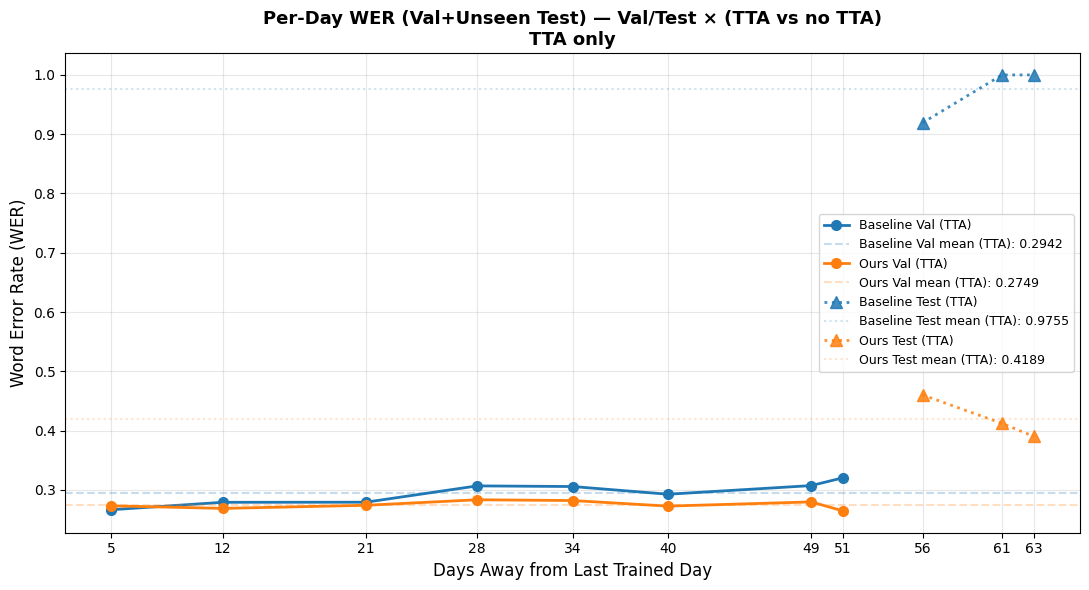

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Val+Unseen Test) — Val/Test × (TTA vs no TTA)\nTTA only'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [ ]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	out_val_set_with_tta=out_val_set_with_tta,
	eval_day_deltas=eval_day_deltas,
	out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name="Val+Unseen Test",
	title_extra="TTA only",
)



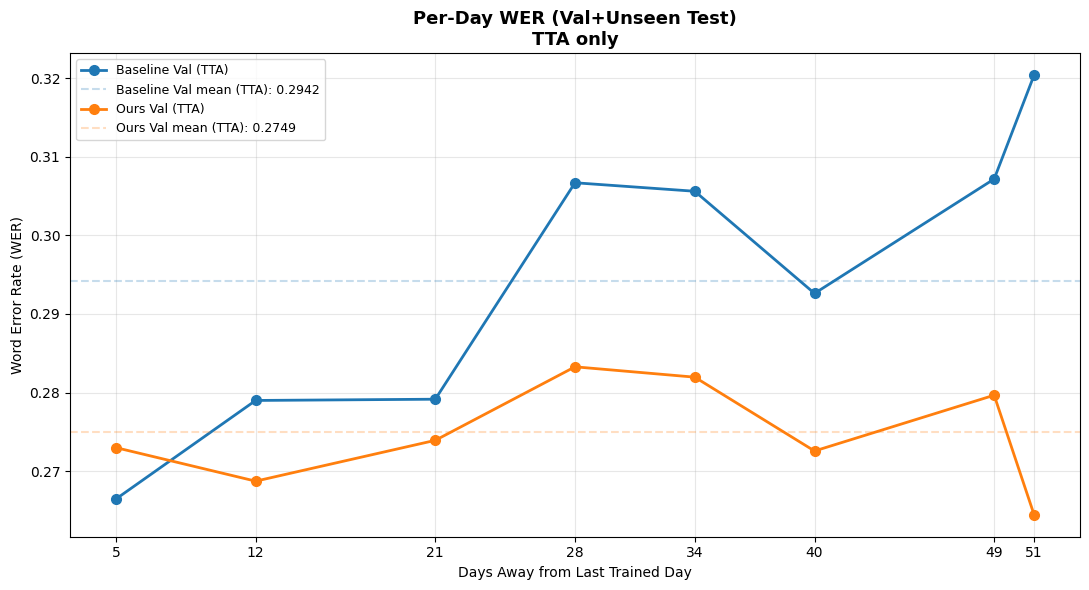

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Val+Unseen Test)\nTTA only'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [ ]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	out_val_set_with_tta=out_val_set_with_tta,
	eval_day_deltas=eval_day_deltas,
	dataset_name="Val+Unseen Test",
	title_extra="TTA only",
)



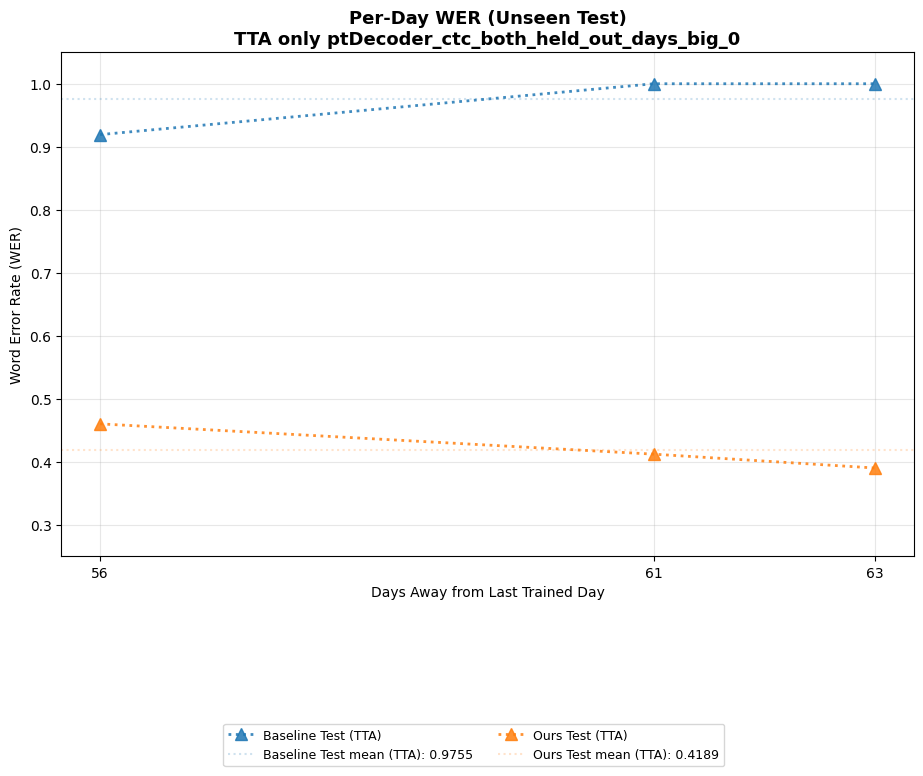

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Unseen Test)\nTTA only ptDecoder_ctc_both_held_out_days_big_0'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [95]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name="Unseen Test",
	title_extra=f"TTA only {Path(data_file).name}",
)

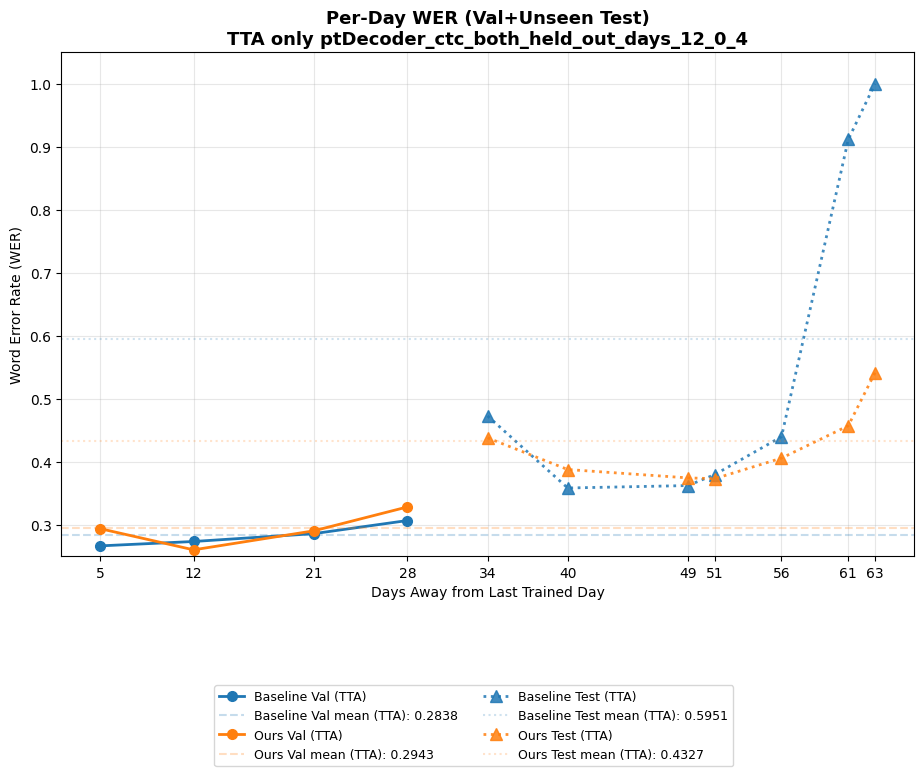

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Val+Unseen Test)\nTTA only ptDecoder_ctc_both_held_out_days_12_0_4'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [13]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	out_val_set_with_tta=out_val_set_with_tta,
	eval_day_deltas=eval_day_deltas,
	out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name="Val+Unseen Test",
	title_extra=f"TTA only {Path(data_file).name}",
)



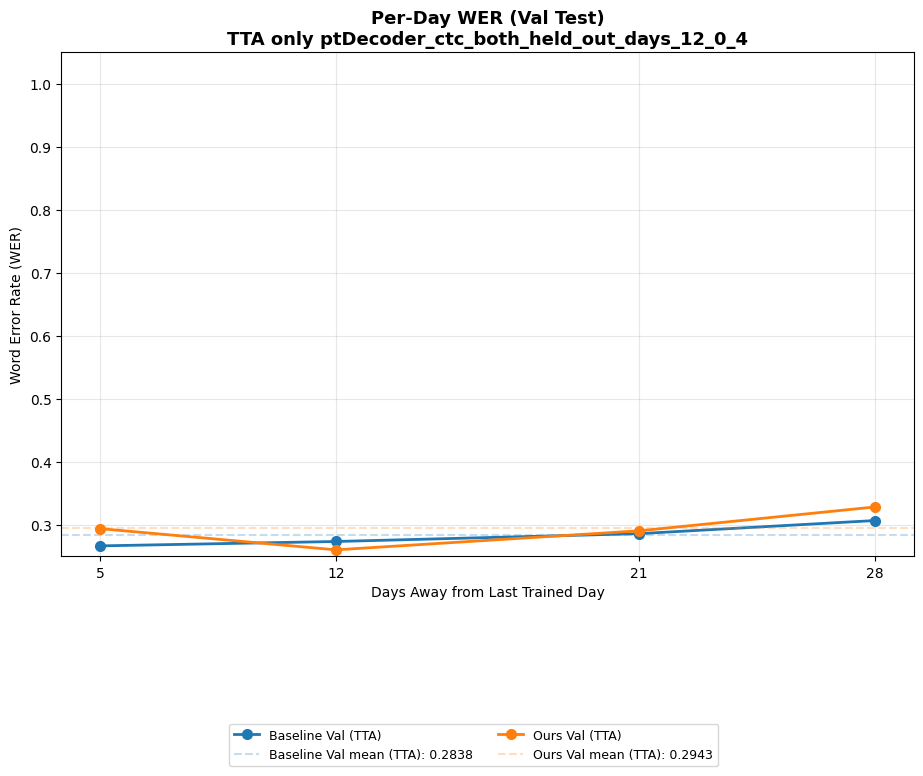

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Val Test)\nTTA only ptDecoder_ctc_both_held_out_days_12_0_4'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [14]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	out_val_set_with_tta=out_val_set_with_tta,
	eval_day_deltas=eval_day_deltas,
	dataset_name="Val Test",
	title_extra=f"TTA only {Path(data_file).name}",
)

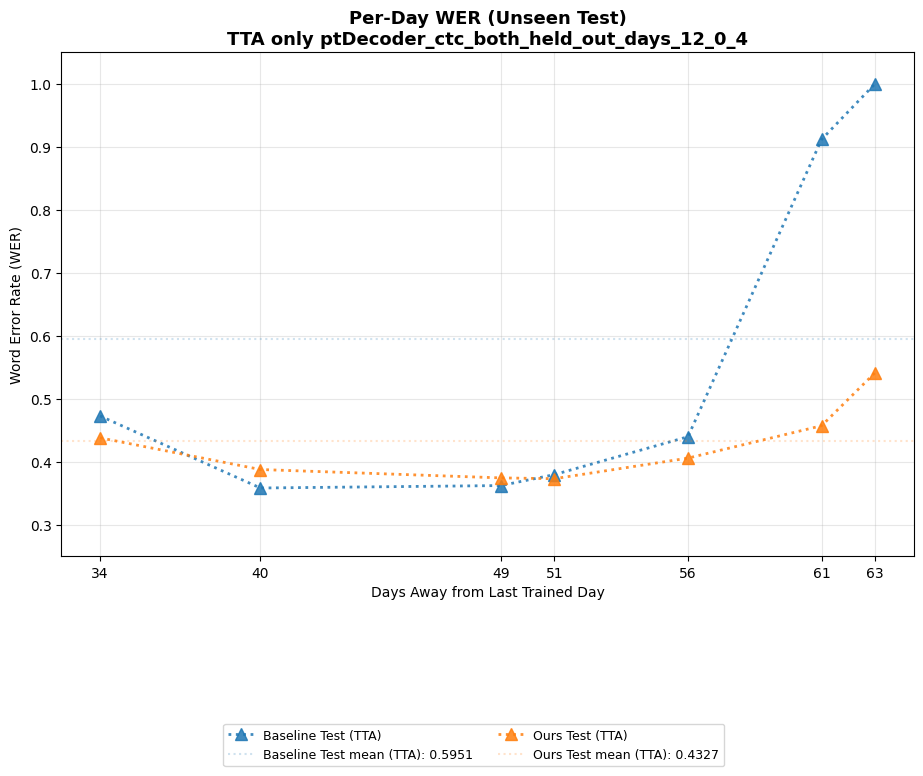

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Unseen Test)\nTTA only ptDecoder_ctc_both_held_out_days_12_0_4'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [15]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name="Unseen Test",
	title_extra=f"TTA only {Path(data_file).name}",
)

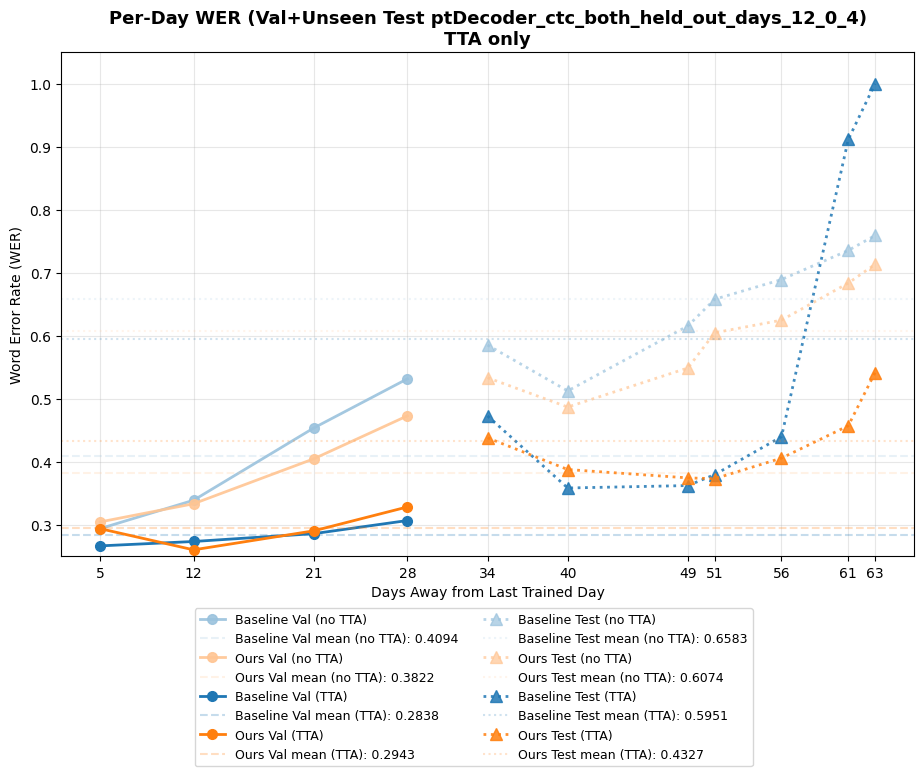

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Val+Unseen Test ptDecoder_ctc_both_held_out_days_12_0_4)\nTTA only'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [16]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64
out_val_set_without_tta["_key_baseline"] = 1
out_val_set_without_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64
out_unseen_test_set_without_tta["_key_baseline"] = 1
out_unseen_test_set_without_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	out_val_set_without_tta=out_val_set_without_tta,
	out_val_set_with_tta=out_val_set_with_tta,
	eval_day_deltas=eval_day_deltas,
	out_unseen_test_set_without_tta=out_unseen_test_set_without_tta,
	out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name=f"Val+Unseen Test {Path(data_file).name}",
	title_extra="TTA only",
)

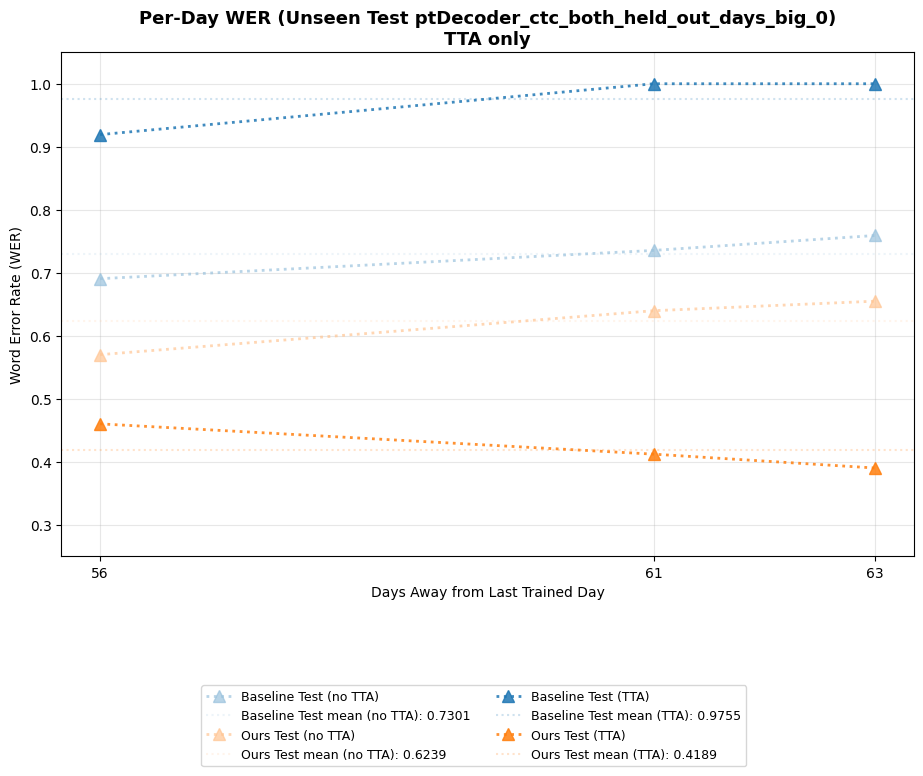

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Unseen Test ptDecoder_ctc_both_held_out_days_big_0)\nTTA only'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [97]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64
out_val_set_without_tta["_key_baseline"] = 1
out_val_set_without_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64
out_unseen_test_set_without_tta["_key_baseline"] = 1
out_unseen_test_set_without_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	# out_val_set_without_tta=out_val_set_without_tta,
	# out_val_set_with_tta=out_val_set_with_tta,
	# eval_day_deltas=eval_day_deltas,
	out_unseen_test_set_without_tta=out_unseen_test_set_without_tta,
	out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name=f"Unseen Test {Path(data_file).name}",
	title_extra="TTA only",
)

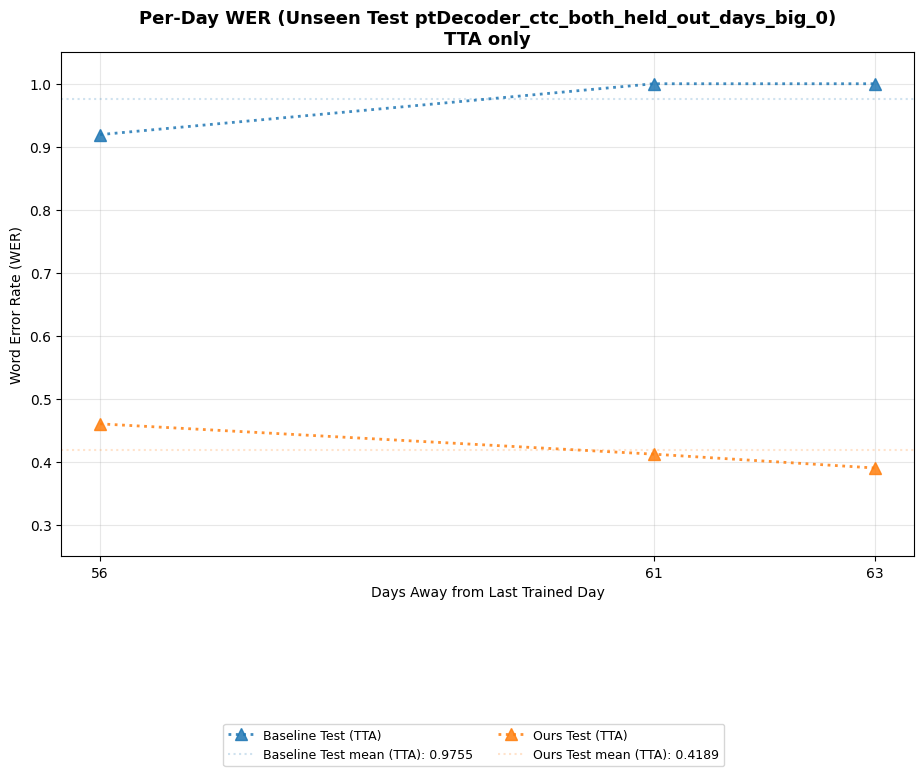

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Unseen Test ptDecoder_ctc_both_held_out_days_big_0)\nTTA only'}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [98]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64
out_val_set_without_tta["_key_baseline"] = 1
out_val_set_without_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64
out_unseen_test_set_without_tta["_key_baseline"] = 1
out_unseen_test_set_without_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	# out_val_set_without_tta=out_val_set_without_tta,
	# out_val_set_with_tta=out_val_set_with_tta,
	# eval_day_deltas=eval_day_deltas,
	# out_unseen_test_set_without_tta=out_unseen_test_set_without_tta,
	out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name=f"Unseen Test {Path(data_file).name}",
	title_extra="TTA only",
)

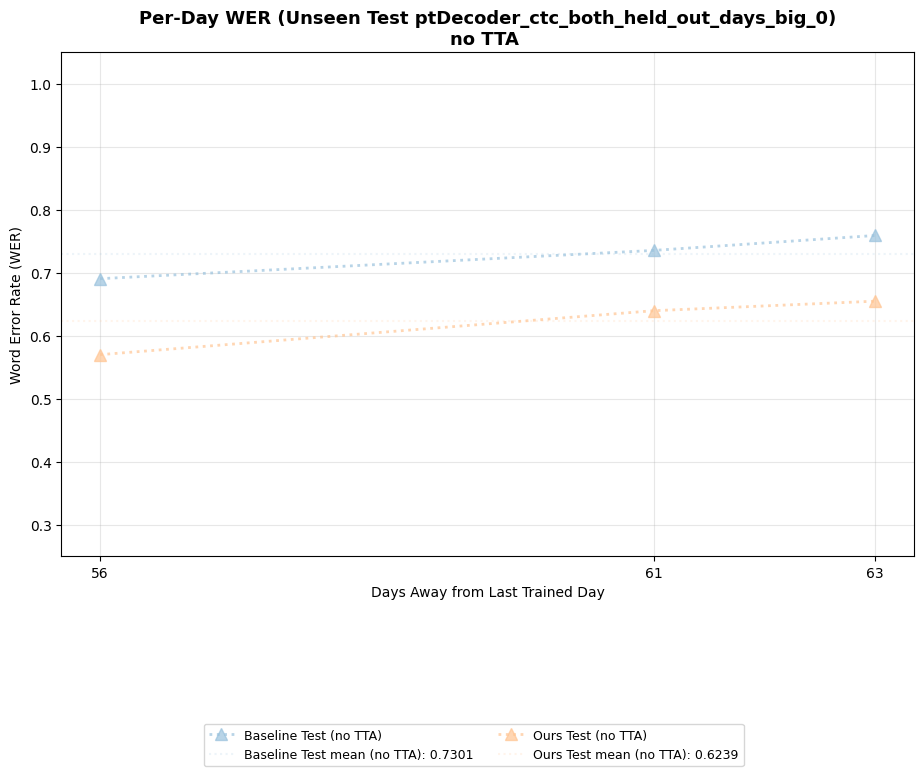

(<Figure size 1100x800 with 1 Axes>,
 <Axes: title={'center': 'Per-Day WER (Unseen Test ptDecoder_ctc_both_held_out_days_big_0)\nno TTA '}, xlabel='Days Away from Last Trained Day', ylabel='Word Error Rate (WER)'>)

In [99]:
out_val_set_with_tta["_key_baseline"] = 1
out_val_set_with_tta["_key_dann"] = 64
out_val_set_without_tta["_key_baseline"] = 1
out_val_set_without_tta["_key_dann"] = 64

out_unseen_test_set_with_tta["_key_baseline"] = 1
out_unseen_test_set_with_tta["_key_dann"] = 64
out_unseen_test_set_without_tta["_key_baseline"] = 1
out_unseen_test_set_without_tta["_key_dann"] = 64

plot_wer_val_test_tta(
	# out_val_set_without_tta=out_val_set_without_tta,
	# out_val_set_with_tta=out_val_set_with_tta,
	# eval_day_deltas=eval_day_deltas,
	out_unseen_test_set_without_tta=out_unseen_test_set_without_tta,
	# out_unseen_test_set_with_tta=out_unseen_test_set_with_tta,
	test_day_deltas=test_day_deltas,
	dataset_name=f"Unseen Test {Path(data_file).name}",
	title_extra="no TTA ",
)